In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# List all CSV files in the /content/ directory
csv_files = glob.glob('/content/*.csv')

# Initialize an empty list to store dataframes
all_dfs = []

print("Loading data from the following CSV files:")
for file_path in csv_files:
    print(f"- {os.path.basename(file_path)}")
    try:
        df_temp = pd.read_csv(file_path)
        # Add a column to identify the source file
        df_temp['Source_File'] = os.path.basename(file_path)
        all_dfs.append(df_temp)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")

# Concatenate all dataframes into a single dataframe
if all_dfs:
    df = pd.concat(all_dfs, ignore_index=True)
    print("\nSuccessfully loaded and combined data from all CSV files.")
    display(df.head())
else:
    print("No CSV files found or loaded.")
    df = pd.DataFrame() # Initialize an empty DataFrame if no files are found

Loading data from the following CSV files:
- spectra_log_Turmeric_Low_Concentration.csv
- spectra_log_Coriander.csv
- spectra_log_Turmeric_High_Concentration.csv

Successfully loaded and combined data from all CSV files.


,Timestamp,IntegrationTime_us,LED_State,Comment,Max_ADC,P0,P1,P2,P3,P4,...,P279,P280,P281,P282,P283,P284,P285,P286,P287,Source_File
0,2026-09-23 09:37:56.816,195152,ON,Turmeric,2559,377,344,339,336,346,...,346,336,343,340,336,347,346,337,341,spectra_log_Turmeric_Low_Concentration.csv
1,2026-09-23 09:38:26.016,161374,ON,Turmeric,2536,379,338,336,334,339,...,341,334,336,336,337,345,336,367,339,spectra_log_Turmeric_Low_Concentration.csv
2,2026-09-23 09:38:56.179,157266,ON,Turmeric,2532,381,339,335,337,334,...,336,327,327,338,304,341,334,338,336,spectra_log_Turmeric_Low_Concentration.csv
3,2026-09-23 09:39:26.246,152234,ON,Turmeric,2593,375,338,335,336,336,...,336,336,336,342,336,347,336,343,347,spectra_log_Turmeric_Low_Concentration.csv
4,2026-09-23 09:39:56.261,143530,ON,Turmeric,2454,375,338,338,332,336,...,339,334,336,339,340,347,338,346,338,spectra_log_Turmeric_Low_Concentration.csv


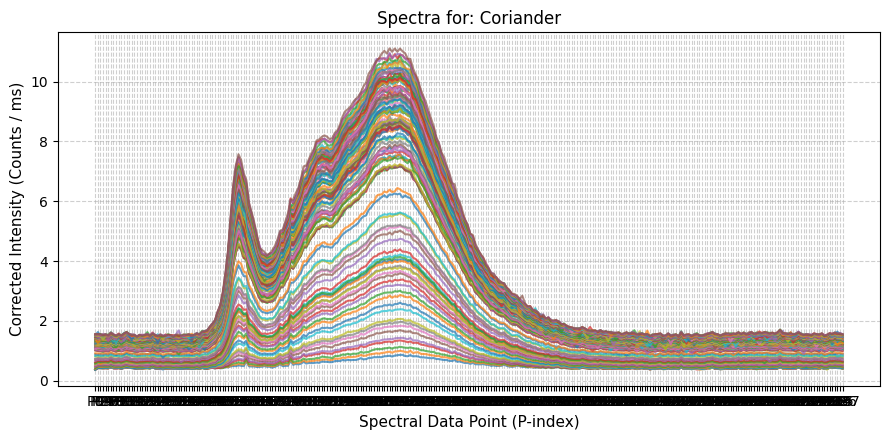

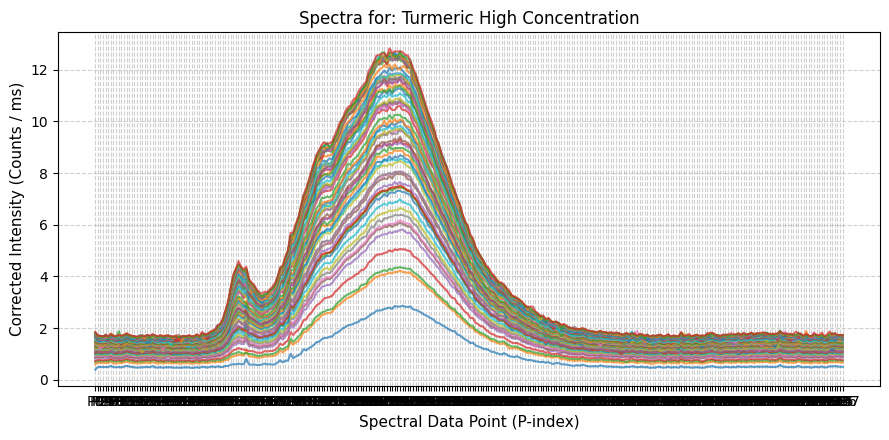

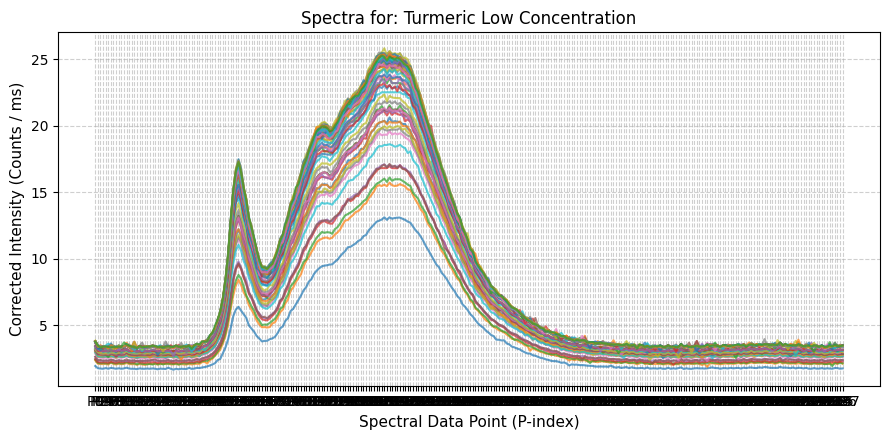

In [65]:
import matplotlib.pyplot as plt

# 1. Identify spectral columns
spectral_columns = [col for col in df.columns if col.startswith('P') and col[1:].isdigit()]

# 2. Correct for dynamic integration time only (scaling to counts per millisecond)
df_corrected = df.copy()
exposure_time_ms = df_corrected['IntegrationTime_us'] / 1000.0
df_corrected[spectral_columns] = df_corrected[spectral_columns].div(exposure_time_ms, axis=0)

# 3. Visualise each category in a separate, smaller plot using pixel indices
group_column = 'Source_File'

for category, group_df in df_corrected.groupby(group_column):
    plt.figure(figsize=(9, 4.5))

    for index, row in group_df.iterrows():
        plt.plot(spectral_columns, row[spectral_columns], alpha=0.7, label=f'Spectrum {index}')

    clean_title = category.replace('spectra_log_', '').replace('.csv', '').replace('_', ' ')
    plt.xlabel('Spectral Data Point (P-index)', fontsize=11)
    plt.ylabel('Corrected Intensity (Counts / ms)', fontsize=11)
    plt.title(f'Spectra for: {clean_title}', fontsize=12)

    if len(group_df) <= 10:
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [66]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Calibration coefficients and function for Serial 21A02875
A0 = 3.086965198E+02
B1 = 2.718912698E+00
B2 = -1.434471882E-03
B3 = -5.759067943E-06
B4 = 3.250344320E-09
B5 = 1.237572658E-11

def pixel_to_wavelength(pix_rel):
    return (A0 +
            B1 * pix_rel +
            B2 * (pix_rel ** 2) +
            B3 * (pix_rel ** 3) +
            B4 * (pix_rel ** 4) +
            B5 * (pix_rel ** 5))

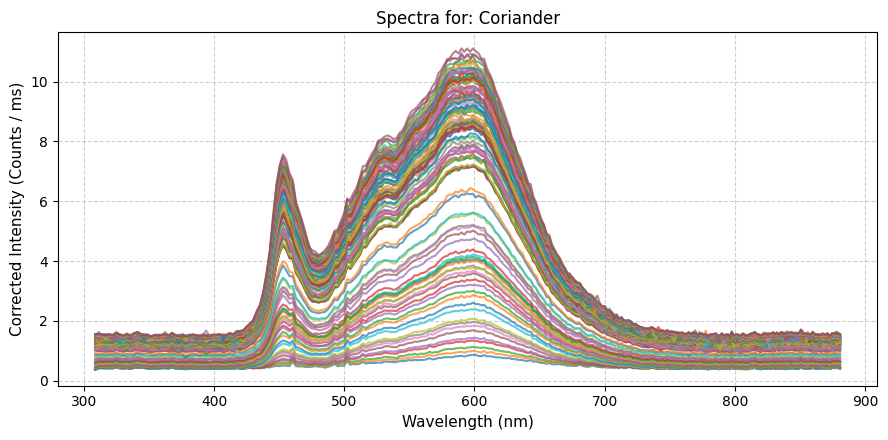

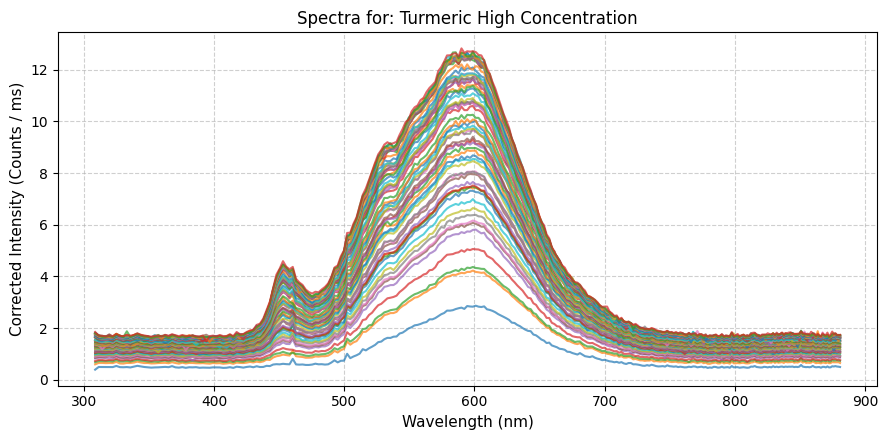

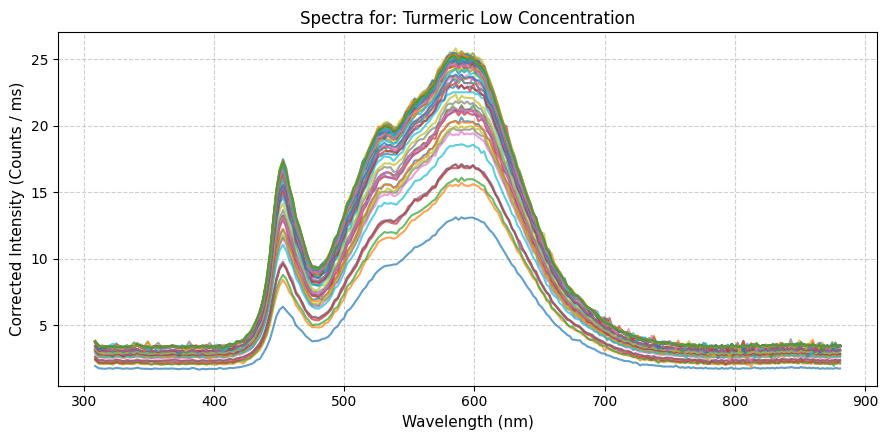

In [67]:
# Identify spectral columns and calculate their wavelengths
spectral_columns = [col for col in df.columns if col.startswith('P') and col[1:].isdigit()]
pixel_indices = np.array([int(col[1:]) for col in spectral_columns])
wavelengths = pixel_to_wavelength(pixel_indices)

# 2. Correct for dynamic integration time only (scaling to counts per millisecond)
df_corrected = df.copy()
exposure_time_ms = df_corrected['IntegrationTime_us'] / 1000.0
df_corrected[spectral_columns] = df_corrected[spectral_columns].div(exposure_time_ms, axis=0)

# 3. Visualise each category in a separate, smaller plot using wavelengths
group_column = 'Source_File'

for category, group_df in df_corrected.groupby(group_column):
    plt.figure(figsize=(9, 4.5))

    for index, row in group_df.iterrows():
        plt.plot(wavelengths, row[spectral_columns], alpha=0.7, label=f'Spectrum {index}')

    clean_title = category.replace('spectra_log_', '').replace('.csv', '').replace('_', ' ')
    plt.xlabel('Wavelength (nm)', fontsize=11)
    plt.ylabel('Corrected Intensity (Counts / ms)', fontsize=11)
    plt.title(f'Spectra for: {clean_title}', fontsize=12)

    if len(group_df) <= 10:
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

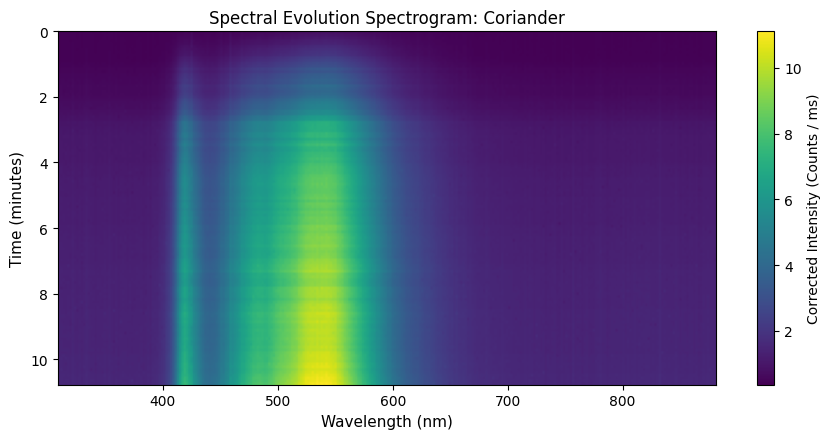

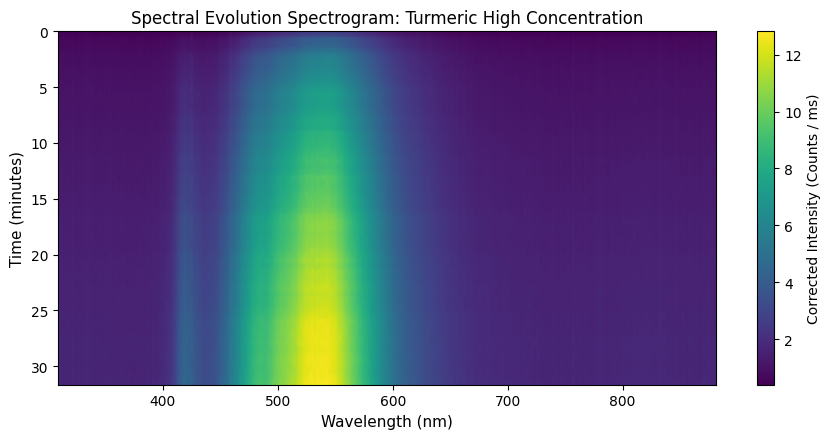

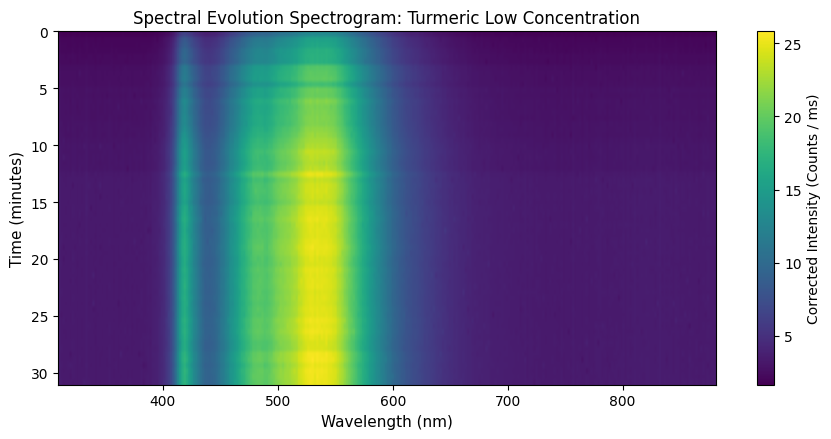

In [68]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Ensure timestamps are datetime objects
df_corrected['Timestamp'] = pd.to_datetime(df_corrected['Timestamp'])

group_column = 'Source_File'

for category, group_df in df_corrected.groupby(group_column):
    # Slightly smaller figure size matching your previous plots
    plt.figure(figsize=(9, 4.5))

    # Calculate time difference from the first timestamp of THIS specific category in minutes
    time_minutes = (group_df['Timestamp'] - group_df['Timestamp'].iloc[0]).dt.total_seconds() / 60.0

    max_time = time_minutes.iloc[-1] if len(time_minutes) > 1 else 1.0
    if max_time == 0:
        max_time = 1.0

    # Extract corrected intensity matrix for the current group
    intensity_matrix = group_df[spectral_columns].values

    # Plot heatmap with calibrated wavelengths on X-axis and time on Y-axis
    im = plt.imshow(
        intensity_matrix,
        aspect='auto',
        extent=[wavelengths[0], wavelengths[-1], max_time, 0.0],
        cmap='viridis'
    )

    # Add colour bar and label axes
    cbar = plt.colorbar(im)
    cbar.set_label('Corrected Intensity (Counts / ms)', fontsize=10)

    clean_title = category.replace('spectra_log_', '').replace('.csv', '').replace('_', ' ')
    plt.xlabel('Wavelength (nm)', fontsize=11)
    plt.ylabel('Time (minutes)', fontsize=11)
    plt.title(f'Spectral Evolution Spectrogram: {clean_title}', fontsize=12)

    plt.grid(False)
    plt.tight_layout()
    plt.show()


=== Automated Dispersion Stability Report: Coriander ===
Sedimentation Rate: 56.526% change per minute
 -> STATUS: Suspension is stable against heavy sedimentation.
Agglomeration Slope: -0.03052 units/min
 -> ALERT: Spectral slope shifting, indicating possible particle growth/flocculation.


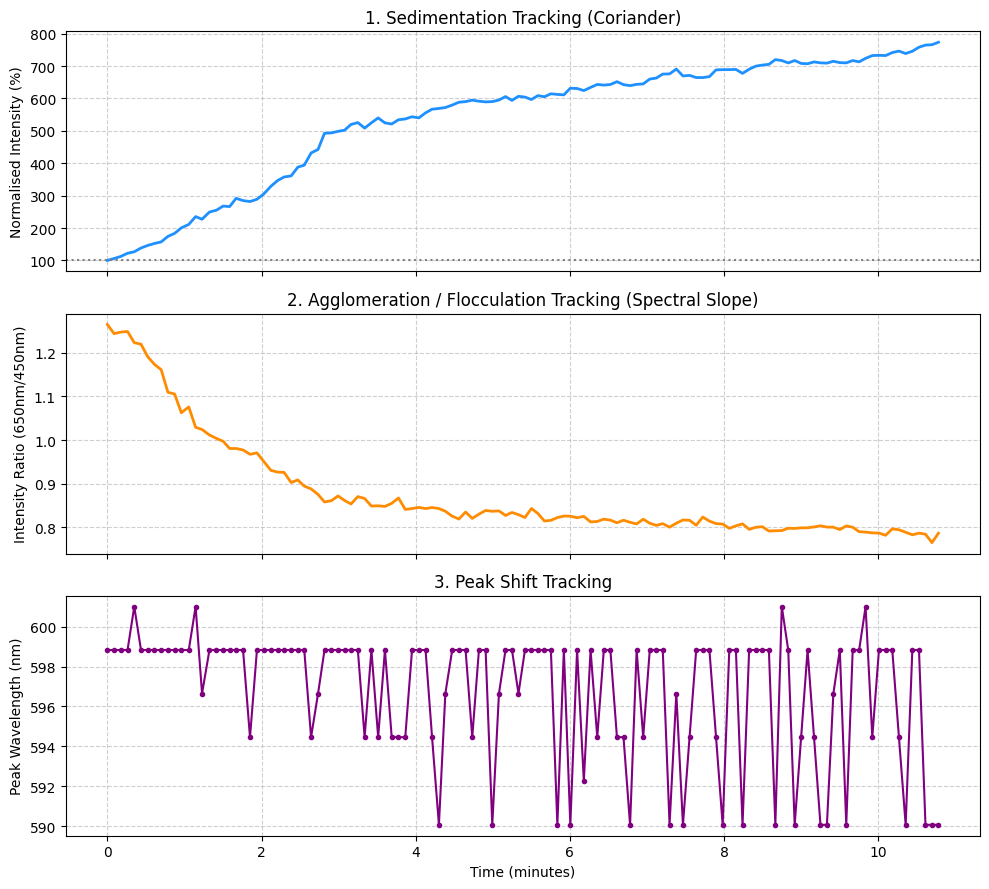


=== Automated Dispersion Stability Report: Turmeric High Concentration ===
Sedimentation Rate: 8.774% change per minute
 -> STATUS: Suspension is stable against heavy sedimentation.
Agglomeration Slope: -0.02782 units/min
 -> ALERT: Spectral slope shifting, indicating possible particle growth/flocculation.


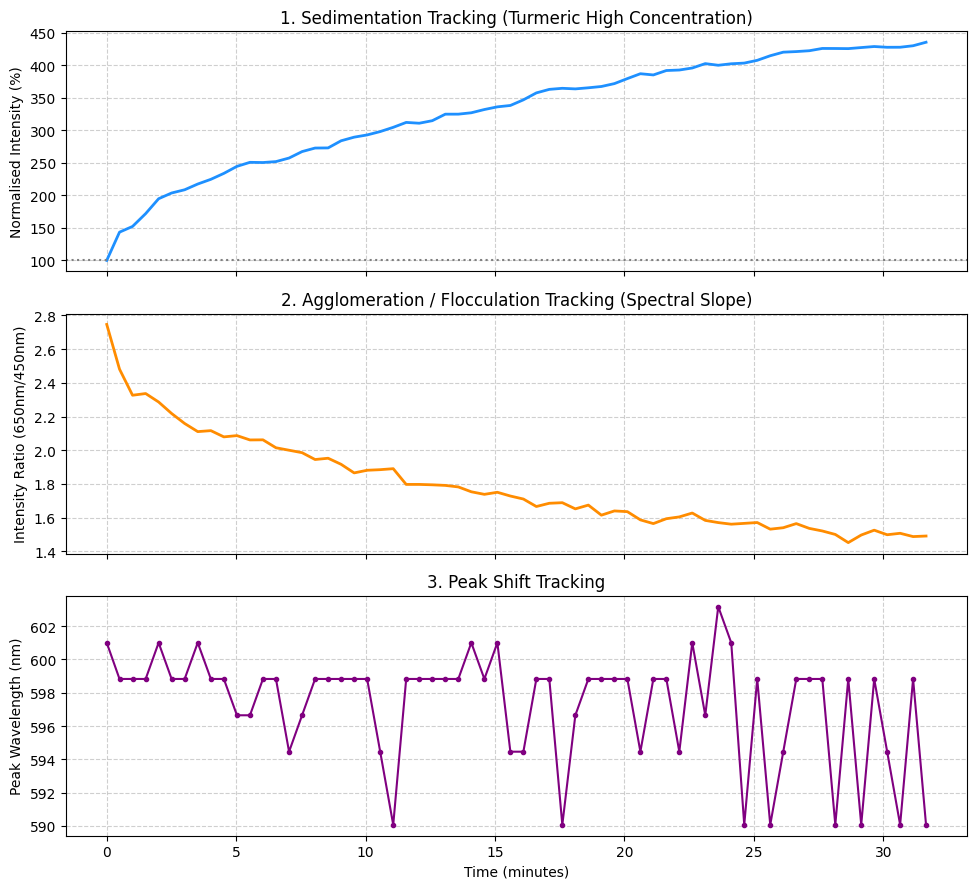


=== Automated Dispersion Stability Report: Turmeric Low Concentration ===
Sedimentation Rate: 2.280% change per minute
 -> STATUS: Suspension is stable against heavy sedimentation.
Agglomeration Slope: -0.00606 units/min
 -> ALERT: Spectral slope shifting, indicating possible particle growth/flocculation.


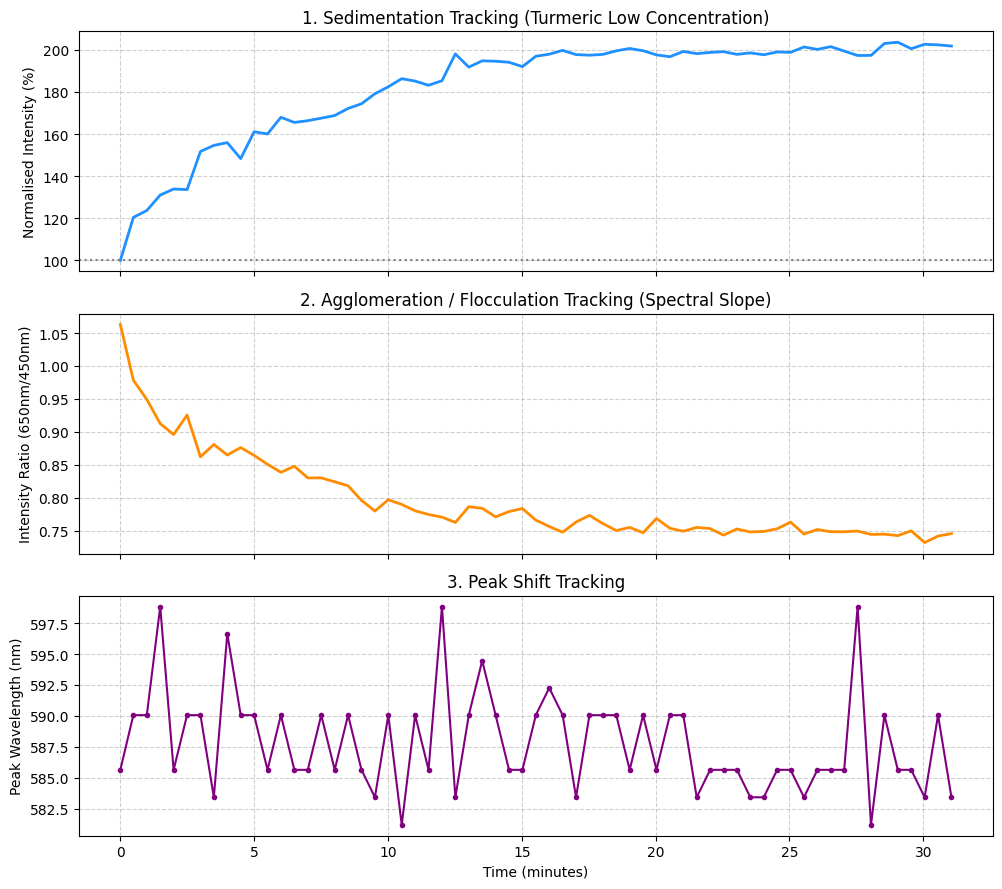

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

def analyze_dispersion_stability(group_df, spectral_cols, wavelengths, category_name):
    """
    Analyses a time-series spectral log for sedimentation, agglomeration, and flocculation.
    """
    group_df = group_df.copy()
    group_df['Timestamp'] = pd.to_datetime(group_df['Timestamp'])
    time_minutes = (group_df['Timestamp'] - group_df['Timestamp'].iloc[0]).dt.total_seconds() / 60.0

    # 1. Metric A: Sedimentation (Total Integrated Intensity)
    total_intensity = group_df[spectral_cols].sum(axis=1)
    sedimentation_norm = (total_intensity / total_intensity.iloc[0]) * 100 # Normalised to % of initial

    # 2. Metric B: Agglomeration/Particle Growth (Spectral Slope / Ratio)
    idx_450 = np.argmin(np.abs(wavelengths - 450))
    idx_650 = np.argmin(np.abs(wavelengths - 650))

    col_450 = spectral_cols[idx_450]
    col_650 = spectral_cols[idx_650]
    spectral_ratio = group_df[col_650] / group_df[col_450]

    # 3. Metric C: Peak Wavelength Shift
    max_idx_cols = group_df[spectral_cols].idxmax(axis=1)
    peak_wavelengths = [wavelengths[spectral_cols.index(col)] for col in max_idx_cols]

    # 4. Linear Trends (Rates of Change)
    if len(time_minutes) > 1:
        sed_slope, _, _, _, _ = linregress(time_minutes, sedimentation_norm)
        ratio_slope, _, _, _, _ = linregress(time_minutes, spectral_ratio)
    else:
        sed_slope, ratio_slope = 0.0, 0.0

    clean_title = category_name.replace('spectra_log_', '').replace('.csv', '').replace('_', ' ')
    print(f"\n=== Automated Dispersion Stability Report: {clean_title} ===")
    print(f"Sedimentation Rate: {sed_slope:.3f}% change per minute")
    if sed_slope < -0.5:
        print(" -> ALERT: Significant sedimentation detected (particles dropping out).")
    else:
        print(" -> STATUS: Suspension is stable against heavy sedimentation.")

    print(f"Agglomeration Slope: {ratio_slope:.5f} units/min")
    if abs(ratio_slope) > 0.001:
        print(" -> ALERT: Spectral slope shifting, indicating possible particle growth/flocculation.")
    else:
        print(" -> STATUS: No major particle size evolution detected.")

    # 5. Plotting Dashboard
    fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

    # Panel 1: Sedimentation Trend
    axes[0].plot(time_minutes, sedimentation_norm, color='dodgerblue', lw=2)
    axes[0].set_ylabel('Normalised Intensity (%)')
    axes[0].set_title(f'1. Sedimentation Tracking ({clean_title})')
    axes[0].grid(True, linestyle='--', alpha=0.6)
    axes[0].axhline(100, color='gray', linestyle=':')

    # Panel 2: Agglomeration / Size Ratio Trend
    axes[1].plot(time_minutes, spectral_ratio, color='darkorange', lw=2)
    axes[1].set_ylabel('Intensity Ratio (650nm/450nm)')
    axes[1].set_title('2. Agglomeration / Flocculation Tracking (Spectral Slope)')
    axes[1].grid(True, linestyle='--', alpha=0.6)

    # Panel 3: Peak Position Shift
    axes[2].plot(time_minutes, peak_wavelengths, color='purple', marker='.', linestyle='-')
    axes[2].set_xlabel('Time (minutes)')
    axes[2].set_ylabel('Peak Wavelength (nm)')
    axes[2].set_title('3. Peak Shift Tracking')
    axes[2].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Run the stability analysis independently for each category file
group_column = 'Source_File'
for category, group_df in df_corrected.groupby(group_column):
    analyze_dispersion_stability(group_df, spectral_columns, wavelengths, category)

In [70]:
import numpy as np
import pandas as pd

group_column = 'Source_File'
spectral_cols = spectral_columns  # using our established variable list

print("=== Pearson Correlation Analysis by Category ===\n")

for category, group_df in df_corrected.groupby(group_column):
    # 1. Recalculate sedimentation_norm locally for this category
    total_intensity = group_df[spectral_cols].sum(axis=1)
    init_intensity = total_intensity.iloc[0] if total_intensity.iloc[0] != 0 else 1.0
    sedimentation_norm = (total_intensity / init_intensity) * 100

    # 2. Recalculate spectral_ratio locally for this category
    idx_450 = np.argmin(np.abs(wavelengths - 450))
    idx_650 = np.argmin(np.abs(wavelengths - 650))

    col_450 = spectral_cols[idx_450]
    col_650 = spectral_cols[idx_650]
    spectral_ratio = group_df[col_650] / group_df[col_450]

    # 3. Calculate the Pearson correlation
    correlation = sedimentation_norm.corr(spectral_ratio)

    # Clean up title for clean output logging
    clean_title = category.replace('spectra_log_', '').replace('.csv', '').replace('_', ' ')

    print(f"Dataset: {clean_title}")
    print(f" -> Pearson Correlation (Sedimentation vs. Spectral Ratio): {correlation:.4f}\n")

=== Pearson Correlation Analysis by Category ===

Dataset: Coriander
 -> Pearson Correlation (Sedimentation vs. Spectral Ratio): -0.9419

Dataset: Turmeric High Concentration
 -> Pearson Correlation (Sedimentation vs. Spectral Ratio): -0.9880

Dataset: Turmeric Low Concentration
 -> Pearson Correlation (Sedimentation vs. Spectral Ratio): -0.9834



### Visualisation of Correlation: Sedimentation vs. Spectral Ratio

The strong negative correlation observed between normalised total intensity (sedimentation) and the spectral ratio (agglemoration/flocculation) can be clearly visualised using a scatter plot. This plot helps to confirm the inverse relationship and understand its linearity.

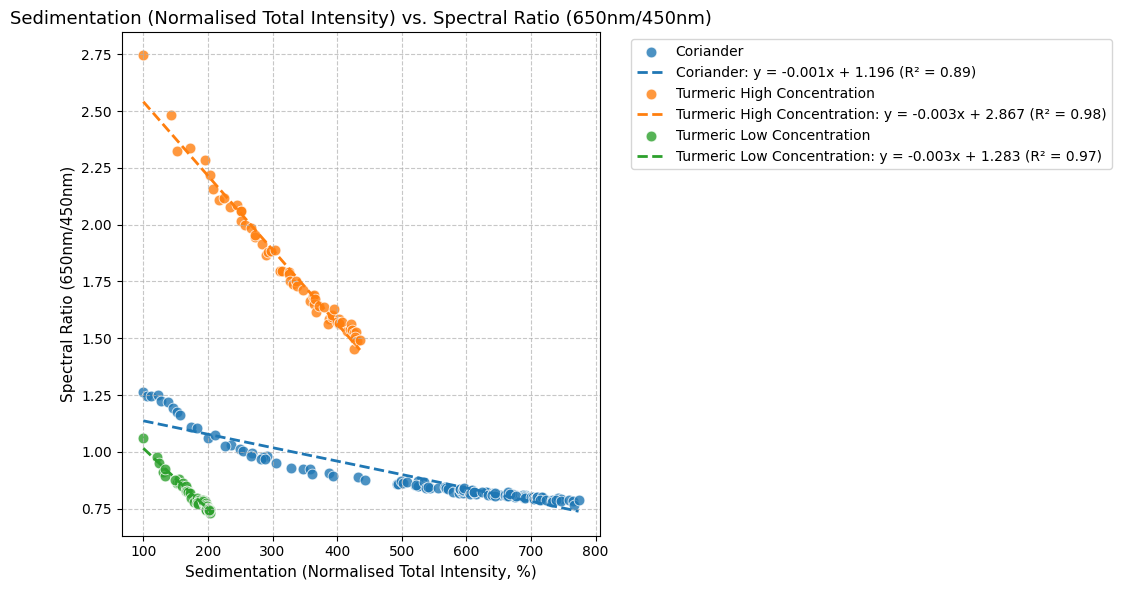

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import linregress

plt.figure(figsize=(11, 6))

group_column = 'Source_File'
spectral_cols = spectral_columns  # Using our established spectral columns list

# Generate a distinct colour palette for the categories
palette = sns.color_palette("tab10", len(df_corrected[group_column].unique()))

for (category, group_df), color in zip(df_corrected.groupby(group_column), palette):
    # 1. Recalculate metrics locally for this category
    total_intensity = group_df[spectral_cols].sum(axis=1)
    init_intensity = total_intensity.iloc[0] if total_intensity.iloc[0] != 0 else 1.0
    sed_norm = (total_intensity / init_intensity) * 100

    idx_450 = np.argmin(np.abs(wavelengths - 450))
    idx_650 = np.argmin(np.abs(wavelengths - 650))
    spec_ratio = group_df[spectral_cols[idx_650]] / group_df[spectral_cols[idx_450]]

    clean_title = category.replace('spectra_log_', '').replace('.csv', '').replace('_', ' ')

    # 2. Scatter plot for the category
    sns.scatterplot(x=sed_norm, y=spec_ratio, color=color, alpha=0.8, s=60, label=f'{clean_title}')

    # 3. Linear regression calculation
    valid_mask = ~np.isnan(sed_norm) & ~np.isnan(spec_ratio)
    if valid_mask.sum() > 1:
        slope, intercept, r_value, _, _ = linregress(sed_norm[valid_mask], spec_ratio[valid_mask])

        # Create regression line coordinates
        x_vals = np.linspace(sed_norm.min(), sed_norm.max(), 100)
        y_vals = slope * x_vals + intercept

        # Format equation string
        sign = "+" if intercept >= 0 else "-"
        eq_label = f'{clean_title}: y = {slope:.3f}x {sign} {abs(intercept):.3f} (R² = {r_value**2:.2f})'

        # Plot regression line
        plt.plot(x_vals, y_vals, color=color, linestyle='--', linewidth=2, label=eq_label)

plt.title('Sedimentation (Normalised Total Intensity) vs. Spectral Ratio (650nm/450nm)', fontsize=13)
plt.xlabel('Sedimentation (Normalised Total Intensity, %)', fontsize=11)
plt.ylabel('Spectral Ratio (650nm/450nm)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

# Spectral and Dispersion Analysis Summary: Spice Suspension Trials

## 1. Overview and Experimental Setup
* **Monitoring Scope:** Time-series optical backscattering measurements were recorded across multiple trials, including **Turmeric (High and Low Concentration)** and **Coriander** dispersions.
* **Data Processing:** Raw signals were corrected for dynamic exposure using sensor integration time parameters and mapped to physical wavelengths (nm) via sensor calibration coefficients, preserving absolute scattering intensity dynamics.

---

## 2. Key Empirical Findings

### Spectral Profiles & Temporal Evolution
* **Primary Features:** Concentration profiles exhibit characteristic multi-wavelength scattering and absorption distributions across the visible light spectrum.
* **Spectrogram Dynamics:** Temporal spectrograms illustrate continuous shifts in signal intensity and distribution over the monitoring window, capturing physical changes in the respective suspensions over time.

### Dispersion and Scattering Metrics
* **Total Intensity Tracking (Sedimentation Proxy):**
  * **Turmeric High:** Normalised total intensity increased progressively from 100% to over 400%.
  * **Turmeric Low:** Normalised total intensity rose from 100% to approximately 200%.
  * **Coriander:** Normalised total intensity climbed steeply from an initial baseline of 100% up to nearly 800% over its monitoring duration.
* **Spectral Slope / Intensity Ratio (650 nm / 450 nm):**
  * All tested spice suspensions demonstrate a consistent downward trend in the multi-wavelength intensity ratio over time as the physical mixture evolves.

### Correlation and Regression Analysis
* **Pearson Correlation ($r$):**
  * **Coriander:** $r = -0.9419$
  * **Turmeric High Concentration:** $r = -0.9880$
  * **Turmeric Low Concentration:** $r = -0.9834$
* **Fitted Models:**
  * **Turmeric High Concentration:** $y = -0.003x + 2.867$ ($R^2 = 0.98$)
  * **Turmeric Low Concentration:** $y = -0.003x + 1.283$ ($R^2 = 0.97$)
  * **Coriander:** $y = -0.001x + 1.196$ ($R^2 = 0.89$)

---

## 3. Analytical Insights and Observations

* **Cross-Substance Consistency:** Introducing Coriander broadens the validity of the optical modeling approach. While Coriander exhibits a distinct slope ($m = -0.001$) compared to Turmeric ($m = -0.003$), it maintains a strong negative linear correlation ($R^2 = 0.89$), proving that the ratio-metric technique captures distinct particulate signatures across different organic materials.
* **Dynamic Range and Scaling:** Coriander reached significantly higher relative backscattering intensity values (approaching 800%), highlighting different agglomeration or scattering properties compared to the Turmeric trials.
* **Substance Discrimination:** The distinct clustering of regression lines and y-intercept offsets across Turmeric (High/Low) and Coriander indicates that multi-wavelength optical backscattering can effectively fingerprint and differentiate particulate types and concentrations dynamically.

---

## 4. Note on Optical Regime (Qualitative Context)

> **Note:** While a rigorous particle-sizing analysis (such as dynamic light scattering) was outside the scope of this experiment, the observed wavelength-dependent backscattering trends are qualitatively consistent with light interaction mechanisms typical of the **Mie scattering regime** (where suspended particle dimensions are comparable to the wavelengths of incident visible light). This is provided purely as a theoretical framework to contextualize the multi-wavelength spectral response, rather than a proven metric.